In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
import textwrap
from pathlib import Path
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE, RandomOverSampler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import roc_curve, classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score, RocCurveDisplay, precision_recall_curve
from sklearn.feature_selection import mutual_info_classif
import shap

# Setup Configurations
RANDOM_STATE = 42
TARGET_COL = "stunting"
cv_obj = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
PRIMARY_SCORING = "roc_auc"
LIGHTGBM_AVAILABLE = True
SHAP_AVAILABLE = True
LIME_AVAILABLE = False


In [2]:
try:
    from IPython.display import display
except ImportError:
    display = print


# Prediksi Risiko Stunting Menggunakan Machine Learning

Notebook ini membangun pipeline machine learning yang ketat secara metodologi
untuk prediksi risiko stunting berdasarkan faktor maternal dan sosioekonomi.
Seluruh proses mengikuti standar penelitian akademik dan bebas dari data leakage.


## Tahap 1: Setup dan Imports


In [3]:
# ─── Configuration ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
TARGET_COL = "stunting"

sns.set_theme(style="whitegrid", context="paper", font_scale=1.08)
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300,
    "savefig.facecolor": "white", "figure.facecolor": "white",
    "axes.facecolor": "white", "font.family": "serif",
    "axes.titlesize": 12, "axes.labelsize": 10.5,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 8.5, "axes.titleweight": "bold",
    "axes.titlepad": 8, "axes.edgecolor": "#D1D5DB",
    "grid.color": "#E5E7EB", "grid.linewidth": 0.7,
})

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data/processed/stunting_pregnancy_features.csv"
MODEL_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = MODEL_DIR / "figures"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Visual constants
CLASS_LABELS = {0: "Not Stunted", 1: "Stunted"}
CLASS_ORDER = ["Not Stunted", "Stunted"]
CLASS_PALETTE = {"Not Stunted": "#4E79A7", "Stunted": "#E15759"}
PRIMARY_BLUE = "#4E79A7"
RISK_RED = "#E15759"
NEUTRAL_GRAY = "#6B7280"
GRID_GRAY = "#E5E7EB"
METRIC_PALETTE = {
    "Accuracy": "#4E79A7", "Precision": "#59A14F",
    "Recall": "#E15759", "F1-Score": "#F28E2B",
    "AUC": "#B07AA1", "ROC-AUC": "#B07AA1",
}

FEATURE_LABELS = {
    "mother_weight": "Berat Badan Ibu",
    "mother_age": "Umur Ibu Saat Hamil",
    "mother_education": "Pendidikan Ibu",
    "birth_order": "Urutan Kelahiran",
    "anc_visits_total": "Kunjungan ANC",
    "iron_pills": "Konsumsi Pil Besi",
    "pregnancy_sickness": "Sakit Parah saat Hamil",
    "birth_location_facility": "Lahir di Faskes",
    "stunting": "Stunting (Target)",
    "is_stunted": "Stunting Status",
    "mother_height_cm": "Mother Height (cm)",
    "mother_education_level": "Mother Education Level",
    "mother_employment_status": "Mother Employment",
    "child_gender": "Child Gender",
    "mother_age_at_birth": "Mother Age at Birth",
    "is_teenage_mother": "Teenage Mother",
    "is_high_risk_mother_age": "High-Risk Age",
    "has_delivery_insurance": "Delivery Insurance",
    "improved_water": "Improved Water",
    "improved_sanitation": "Improved Sanitation",
    "home_ownership": "Home Ownership",
    "has_electricity": "Electricity",
    "has_refrigerator": "Refrigerator",
    "has_tv": "Television",
    "anc_clinic_midwife": "ANC Clinic/Midwife",
    "anc_hospital": "ANC Hospital",
    "anc_traditional_other": "ANC Traditional",
    "anc_unknown": "ANC Unknown",
    # Engineered features
    "mother_short_stature": "Short Stature Mother (<150cm)",
    "mother_education_low": "Low Education (≤SMP)",
    "wealth_index": "Wealth Index",
    "anc_formal": "Formal ANC Access",
    # Advanced Engineered Features
    "mother_age_group": "Mother Age Group",
    "wealth_edu_interaction": "Wealth × Education",
    "height_edu_interaction": "Short Stature × Low Edu",
    "healthy_house": "Healthy House Score",
    "asset_score": "Asset Score",

    "maternal_miscarriages": "Maternal Miscarriages",
    "maternal_parity": "Maternal Parity",
    "low_birth_weight": "Low Birth Weight (<2.5kg)",
    "maternal_anemia": "Maternal Anemia (Hb<11)",
    "maternal_bmi_underweight": "Mother Underweight (BMI<18.5)",
    "maternal_bmi_overweight": "Mother Overweight (BMI>=25)",
    "adequate_anc": "Adequate ANC (>=4 Visits)",
    "food_expenditure_quintile": "Food Expenditure Quintile",
    "child_breastfed": "Breastfed",
    "child_had_diarrhea": "Child had Diarrhea",
    "child_had_ari": "Child had ARI",
    "age_in_months": "Child Age (Months)",
    "maternal_bmi": "Maternal BMI",
    "maternal_hemoglobin": "Maternal Hemoglobin",
    "child_birth_weight": "Birth Weight (kg)",
    "maternal_anc_visits": "ANC Visits",
    "hh_food_expenditure_weekly": "Weekly Food Expenditure",

    # V2 Features
    "father_height_cm": "Father Height (cm)",
    "household_size": "Household Size",
    "number_of_under5_children": "Under 5 Children in HH",
    "mother_age_first_pregnancy": "Mother Age at First Pregnancy",
    "pregnancy_interval": "Pregnancy Interval (Years)",
    "food_expenditure": "Food Expenditure",
    "meat_expenditure": "Meat Expenditure",
    "fish_expenditure": "Fish Expenditure",
    "egg_milk_expenditure": "Egg & Milk Expenditure",
    "environmental_risk_score": "Environmental Risk Score",
    "maternal_nutrition_score": "Maternal Nutrition Score",
    "parental_height_score": "Parental Height Score",
    "short_parent_risk": "Short Parent Risk Score",
    "poverty_nutrition_risk": "Poverty & Nutrition Risk",
    "maternal_risk_score": "Maternal Clinical Risk",
}


def pretty_name(name, width=24):
    label = FEATURE_LABELS.get(str(name), str(name).replace("_", " ").title())
    return "".join(textwrap.wrap(label, width=width, break_long_words=False))


def style_axis(ax, grid_axis="y"):
    ax.grid(True, axis=grid_axis, color=GRID_GRAY, linewidth=0.7, alpha=0.95)
    if grid_axis == "y":
        ax.grid(False, axis="x")
    elif grid_axis == "x":
        ax.grid(False, axis="y")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#D1D5DB")
        ax.spines[spine].set_linewidth(0.8)
    ax.tick_params(colors="#374151", length=3)


def save_figure(fig, filename, top=0.94):
    fig.tight_layout(rect=[0, 0, 1, top])
    fig.savefig(FIGURE_DIR / filename, bbox_inches="tight", dpi=300, facecolor="white")


def add_bar_labels(ax, fmt="{:.0f}", fontsize=8, padding=2):
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            labels.append("" if pd.isna(value) else fmt.format(value))



## Tahap 1: Audit Dataset

Melakukan analisis menyeluruh terhadap dataset untuk memahami karakteristik data,
distribusi kelas, missing values, dan potensi masalah sebelum pemodelan.


In [4]:
df = pd.read_csv(DATA_PATH)
if 'mother_pidlink' in df.columns:
    df = df.drop(columns=['mother_pidlink', 'child_pidlink'])

print(f"Duplicate rows found: {df.duplicated().sum()}")
df = df.drop_duplicates(keep='first').reset_index(drop=True)
# mother_height is now valid, keeping it.
print(f"Dataset shape: {df.shape[0]} baris × {df.shape[1]} kolom")
display(df.head())


Duplicate rows found: 0
Dataset shape: 5901 baris × 16 kolom


,stunting,mother_height,mother_weight,maternal_bmi,maternal_hemoglobin,mother_age,mother_education,birth_order,anc_visits_total,iron_pills,pregnancy_sickness,birth_location_facility,birth_weight,child_gender,child_height,child_age_years
0,1.0,139.4,41.2,21.201748,12.5,26.0,2.0,4.0,0.0,1.0,0,0.0,3.1,3.0,81.720985,3.0
1,1.0,156.6,54.2,22.101196,10.4,36.0,2.0,9.0,0.0,1.0,0,0.0,3.1,1.0,88.755058,3.0
2,1.0,156.6,54.2,22.101196,10.4,38.0,2.0,10.0,0.0,1.0,0,0.0,3.1,1.0,63.022574,1.0
3,1.0,151.6,45.9,19.971665,12.1,37.0,5.0,7.0,0.0,1.0,0,0.0,3.1,1.0,90.710101,3.0
4,0.0,147.6,71.6,32.865505,11.7,32.0,2.0,5.0,0.0,1.0,0,0.0,3.1,1.0,69.441715,0.0


In [5]:
# Statistik Deskriptif
print("=== Statistik Deskriptif ===")
display(df.describe().round(3))


=== Statistik Deskriptif ===


,stunting,mother_height,mother_weight,maternal_bmi,maternal_hemoglobin,mother_age,mother_education,birth_order,anc_visits_total,iron_pills,pregnancy_sickness,birth_location_facility,birth_weight,child_gender,child_height,child_age_years
count,5901.000,5901.000,5901.000,5901.000,5901.000,5901.000,5901.000,5901.000,5901.000,5901.000,5901.000,5901.000,5901.000,5901.000,5901.000,5901.000
mean,0.242,151.711,56.113,24.348,12.451,27.589,19.707,1.638,9.067,0.858,0.423,0.366,3.163,1.965,87.127,2.443
std,0.428,5.405,11.323,4.564,1.379,5.886,27.030,0.990,4.346,0.349,0.494,0.482,0.643,0.999,16.055,1.715
min,0.000,104.600,25.700,12.040,5.600,13.000,2.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000,40.841,0.000
25%,0.000,148.000,48.100,21.107,11.600,23.000,3.000,1.000,7.000,1.000,0.000,0.000,2.900,1.000,75.236,1.000
50%,0.000,151.600,54.500,23.702,12.500,27.000,5.000,1.000,9.000,1.000,0.000,0.000,3.100,1.000,88.348,2.000
75%,0.000,155.300,62.700,27.003,13.400,32.000,60.000,2.000,11.000,1.000,1.000,1.000,3.500,3.000,99.740,4.000
max,1.000,174.500,140.700,56.006,17.200,51.000,95.000,12.000,45.000,1.000,1.000,1.000,9.990,3.000,165.182,5.000


In [6]:
# Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Percentage": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0]
if len(missing_df) == 0:
    print("✓ Tidak ditemukan missing values.")
else:
    display(missing_df)


✓ Tidak ditemukan missing values.


In [7]:
# Distribusi Target
print("=== Distribusi Kelas Target ===")
target_dist = df[TARGET_COL].value_counts()
target_pct = (df[TARGET_COL].value_counts(normalize=True) * 100).round(2)
target_summary = pd.DataFrame({"Count": target_dist, "Percentage (%)": target_pct})
target_summary.index = target_summary.index.map(CLASS_LABELS)
display(target_summary)

imbalance_ratio = target_dist[0] / target_dist[1]
print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"Kategori: {'Moderate Imbalance' if imbalance_ratio < 4 else 'Severe Imbalance'}")


=== Distribusi Kelas Target ===


,Count,Percentage (%)
stunting,,
Not Stunted,4475,75.83
Stunted,1426,24.17


Imbalance Ratio: 3.14:1
Kategori: Moderate Imbalance


In [8]:
# Near-Constant Feature Detection
print("=== Deteksi Fitur Near-Constant ===")
for col in df.columns:
    if col == TARGET_COL:
        continue
    counts = df[col].value_counts(normalize=True)
    if not counts.empty:
        dominant_pct = counts.iloc[0] * 100
        if dominant_pct > 95:
            print(f"  ⚠ {col}: {dominant_pct:.1f}% bernilai sama → NEAR-CONSTANT")


=== Deteksi Fitur Near-Constant ===


In [9]:
# Correlation with Target
print("=== Korelasi dengan Target (|r|) ===")
corr_target = df.corr(numeric_only=True)[TARGET_COL].abs().sort_values(ascending=False)
corr_target = corr_target.drop(TARGET_COL)
display(corr_target.round(4))


=== Korelasi dengan Target (|r|) ===


child_height               0.3562
mother_height              0.1494
birth_weight               0.1103
mother_weight              0.1055
child_age_years            0.1028
birth_order                0.0623
mother_age                 0.0595
maternal_bmi               0.0583
maternal_hemoglobin        0.0512
anc_visits_total           0.0473
mother_education           0.0452
child_gender               0.0446
pregnancy_sickness         0.0251
iron_pills                 0.0023
birth_location_facility    0.0019
Name: stunting, dtype: float64

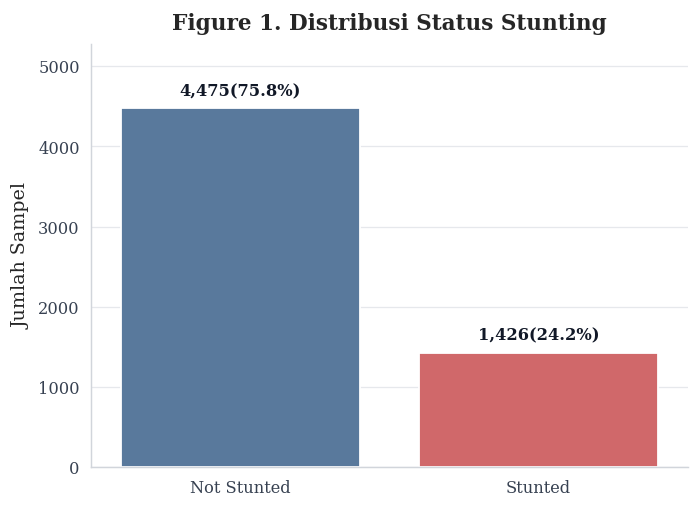

In [10]:
# Visualisasi: Target Distribution
plot_df = df.copy()
plot_df["Stunting Status"] = plot_df[TARGET_COL].map(CLASS_LABELS)

target_counts = plot_df["Stunting Status"].value_counts().reindex(CLASS_ORDER, fill_value=0)
fig, ax = plt.subplots(figsize=(5.5, 4.2))
sns.barplot(x=target_counts.index, y=target_counts.values, palette=CLASS_PALETTE, ax=ax, edgecolor="white", linewidth=1.0)
for idx, value in enumerate(target_counts.values):
    pct = value / len(plot_df) * 100
    ax.text(idx, value + max(target_counts.values) * 0.025, f"{value:,}({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9, fontweight="bold", color="#111827")
ax.set_title("Figure 1. Distribusi Status Stunting")
ax.set_xlabel("")
ax.set_ylabel("Jumlah Sampel")
ax.set_ylim(0, max(target_counts.values) * 1.18)
style_axis(ax)
save_figure(fig, "eda_target_distribution_clean.png", top=0.96)
plt.show()


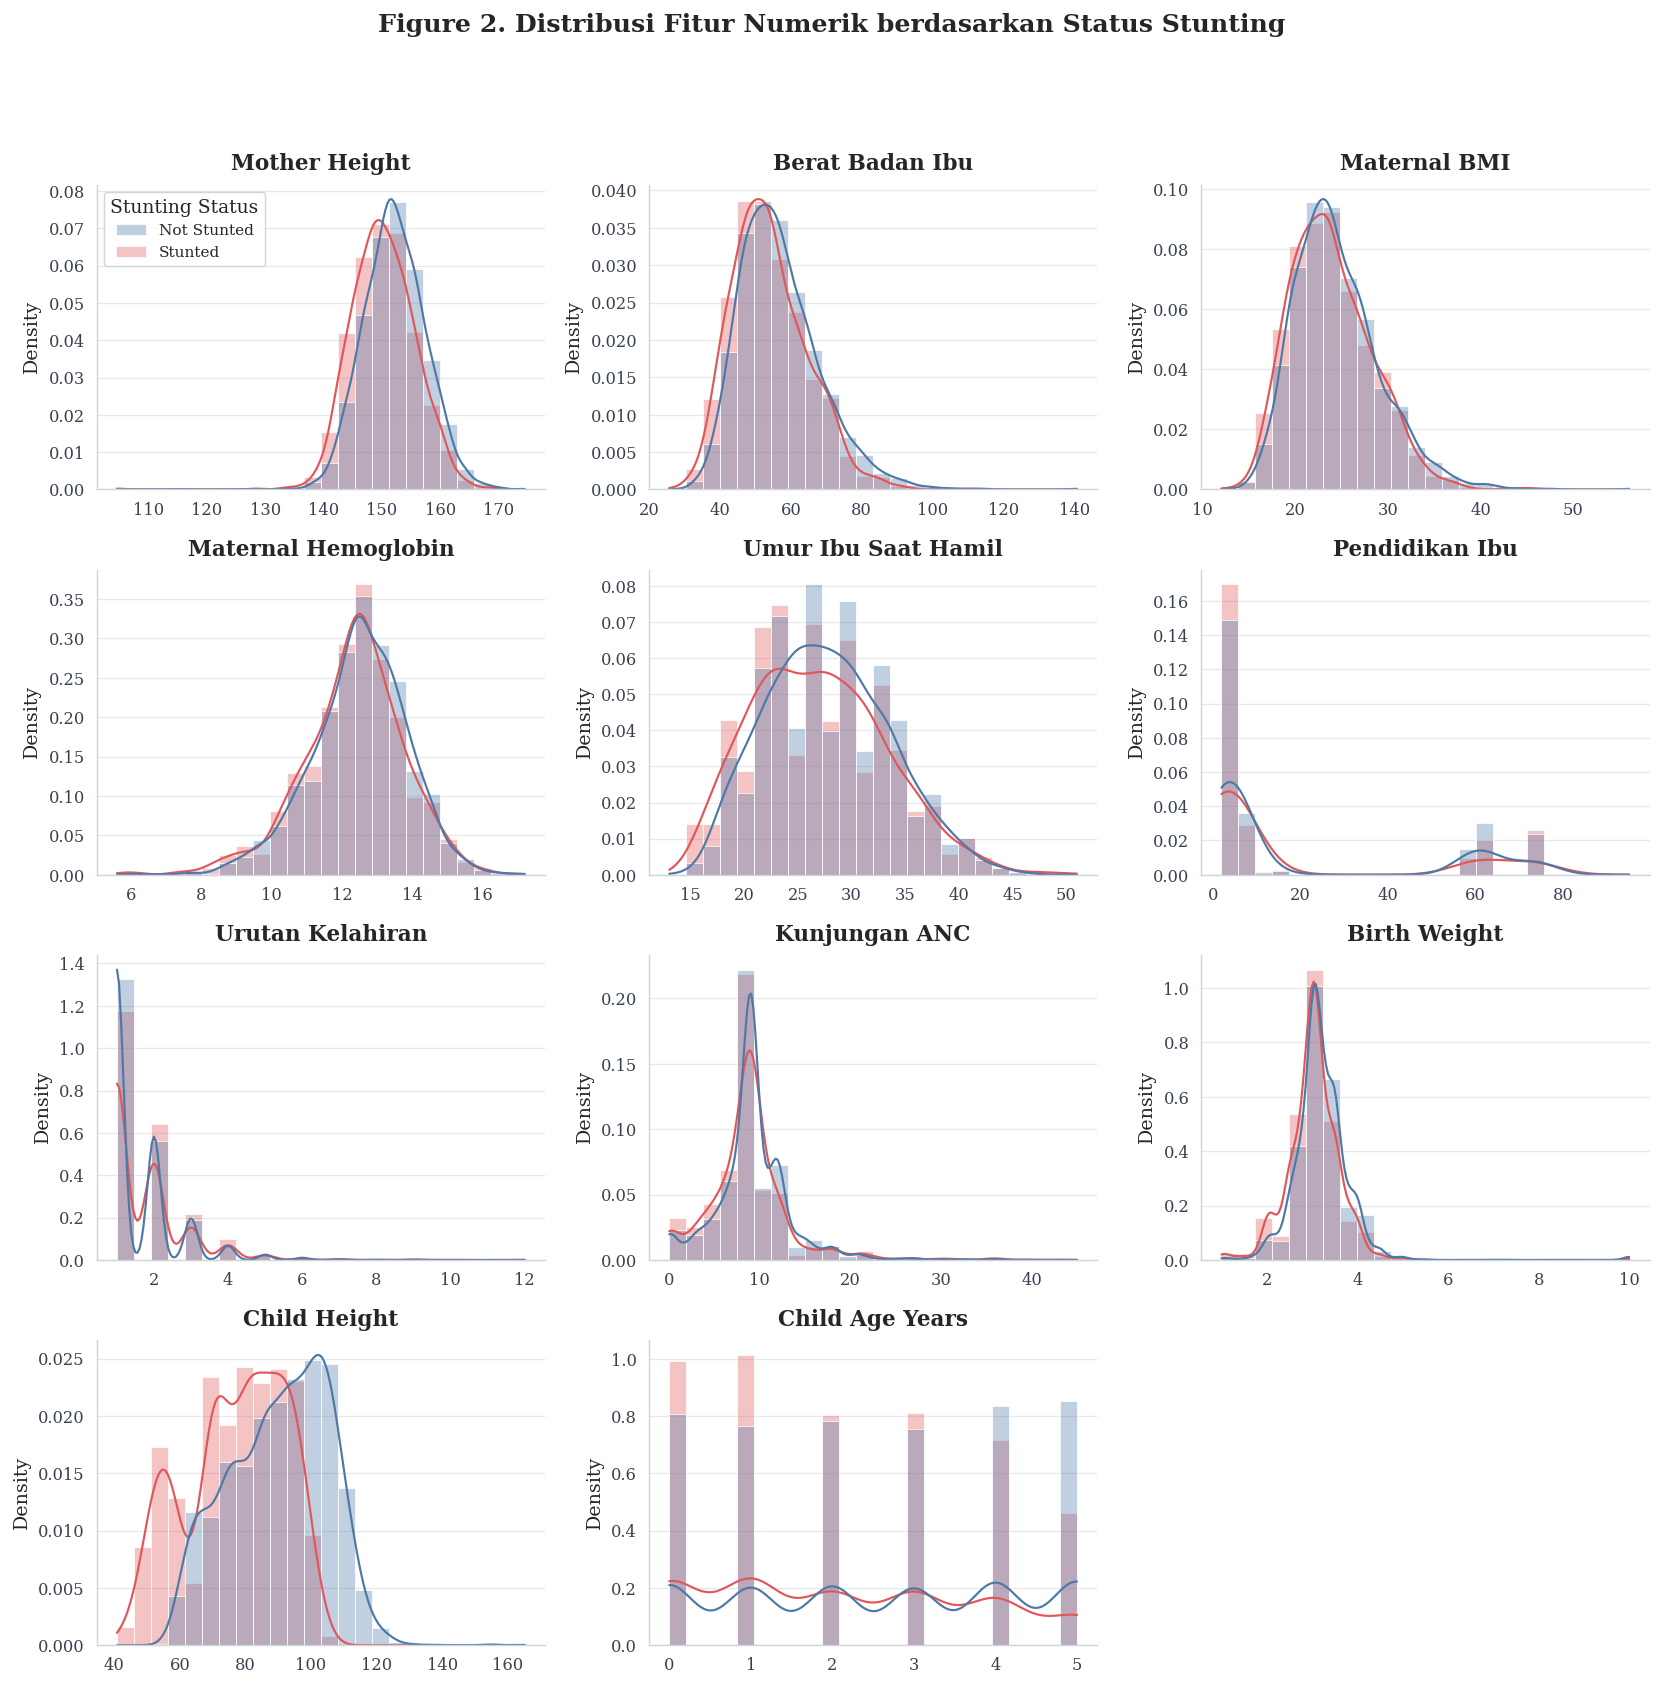

In [11]:
# Visualisasi: Numerical Feature Distributions
numeric_cols = [col for col in df.select_dtypes(include=np.number).columns
                if col != TARGET_COL and df[col].nunique(dropna=True) > 5]
if numeric_cols:
    n_cols_plot = min(3, len(numeric_cols))
    n_rows_plot = math.ceil(len(numeric_cols) / n_cols_plot)
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(4.3 * n_cols_plot, 3.25 * n_rows_plot), squeeze=False)
    for idx, col in enumerate(numeric_cols):
        ax = axes.flatten()[idx]
        sns.histplot(data=plot_df, x=col, hue="Stunting Status", hue_order=CLASS_ORDER,
                     palette=CLASS_PALETTE, bins=24, kde=True, stat="density",
                     common_norm=False, alpha=0.35, linewidth=0.4, edgecolor="white",
                     ax=ax, legend=(idx == 0))
        ax.set_title(pretty_name(col, width=28))
        ax.set_xlabel("")
        ax.set_ylabel("Density")
        style_axis(ax)
    for empty_ax in axes.flatten()[len(numeric_cols):]:
        empty_ax.axis("off")
    fig.suptitle("Figure 2. Distribusi Fitur Numerik berdasarkan Status Stunting",
                 fontsize=14, fontweight="bold", y=0.995)
    save_figure(fig, "eda_numerical_distributions_paper_style.png", top=0.95)
    plt.show()


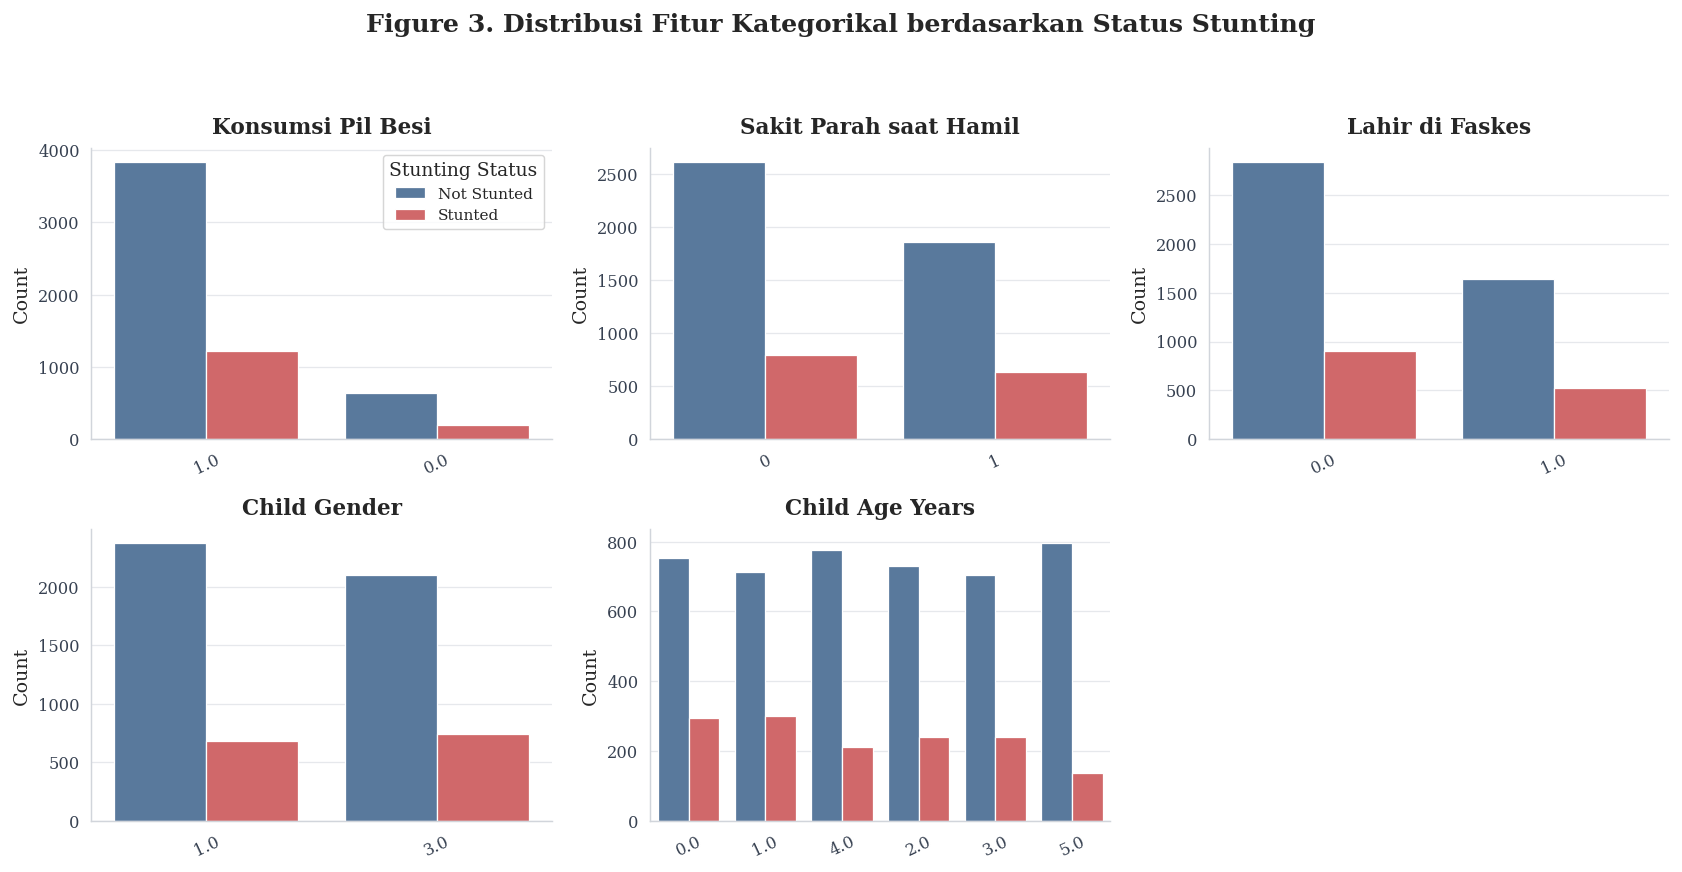

In [12]:
# Visualisasi: Categorical Feature Distributions
categorical_cols = [col for col in df.columns
                    if col != TARGET_COL and df[col].nunique(dropna=True) <= 6]
max_cat = min(len(categorical_cols), 12)
categorical_cols = categorical_cols[:max_cat]

if categorical_cols:
    n_cols_plot = 3
    n_rows_plot = math.ceil(len(categorical_cols) / n_cols_plot)
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(4.35 * n_cols_plot, 3.35 * n_rows_plot), squeeze=False)
    for idx, col in enumerate(categorical_cols):
        ax = axes.flatten()[idx]
        tmp = plot_df[[col, "Stunting Status"]].dropna().copy()
        tmp[col] = tmp[col].astype(str)
        order = tmp[col].value_counts().index.tolist()[:8]
        sns.countplot(data=tmp, x=col, hue="Stunting Status", hue_order=CLASS_ORDER,
                      order=order, palette=CLASS_PALETTE, ax=ax, edgecolor="white", linewidth=0.7)
        ax.set_title(pretty_name(col, width=28))
        ax.set_xlabel("")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=25)
        style_axis(ax)
        legend = ax.get_legend()
        if legend is not None:
            if idx == 0:
                legend.set_title("Stunting Status")
            else:
                legend.remove()
    for empty_ax in axes.flatten()[len(categorical_cols):]:
        empty_ax.axis("off")
    fig.suptitle("Figure 3. Distribusi Fitur Kategorikal berdasarkan Status Stunting",
                 fontsize=14, fontweight="bold", y=0.995)
    save_figure(fig, "eda_categorical_distributions_paper_style.png", top=0.95)
    plt.show()


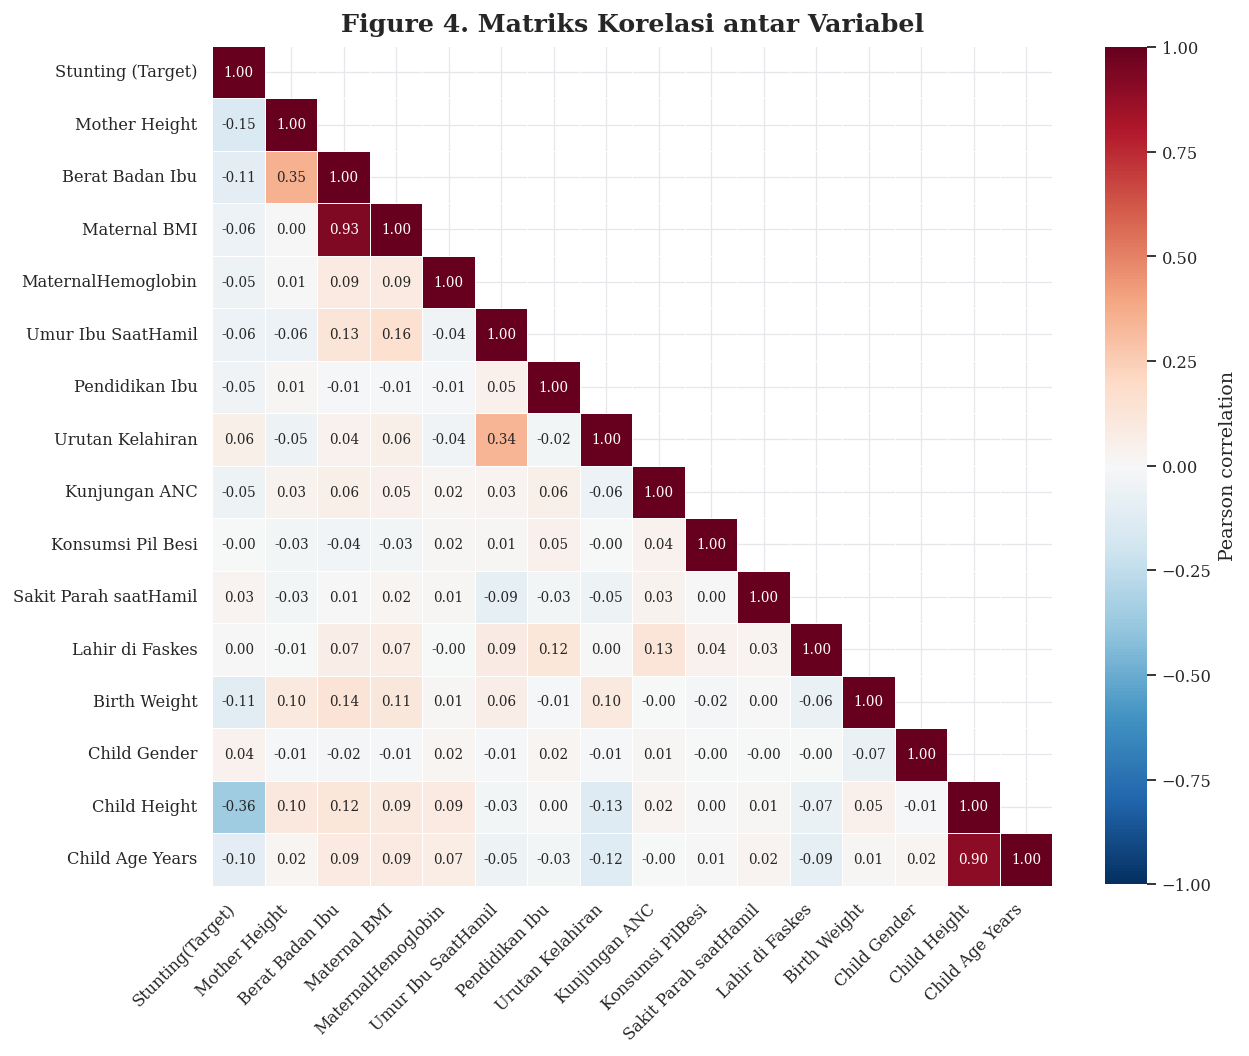

In [13]:
# Visualisasi: Correlation Matrix
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(max(8, 0.62 * corr.shape[1]), max(6.8, 0.58 * corr.shape[0])))
sns.heatmap(corr, mask=mask, annot=(corr.shape[0] <= 20), fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.45, linecolor="white",
            cbar_kws={"shrink": 0.78, "label": "Pearson correlation"}, annot_kws={"fontsize": 7.5}, ax=ax)
ax.set_title("Figure 4. Matriks Korelasi antar Variabel", fontsize=14, fontweight="bold")
ax.set_xticklabels([pretty_name(l.get_text(), width=16) for l in ax.get_xticklabels()], rotation=45, ha="right")
ax.set_yticklabels([pretty_name(l.get_text(), width=18) for l in ax.get_yticklabels()], rotation=0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "correlation_matrix_paper_style.png", bbox_inches="tight", dpi=300, facecolor="white")
plt.show()


## Tahap 2: Data Preprocessing

Pemisahan data dilakukan PERTAMA sebelum langkah apapun untuk mencegah data leakage.
Test set dikunci total dan tidak akan disentuh sampai evaluasi akhir.


In [14]:
groups = None
print("--- FEATURE ENGINEERING ---")
# Kategori usia ibu: <20 (0), 20-35 (1), >35 (2)
df['mother_age_cat'] = pd.cut(df['mother_age'], bins=[0, 19.9, 35.9, 100], labels=[0, 1, 2]).astype(float)

# Kategori ANC: Kurang <4 (0), Cukup 4-6 (1), Sangat Baik >6 (2)
df['anc_cat'] = pd.cut(df['anc_visits_total'], bins=[-1, 3.9, 6.9, 100], labels=[0, 1, 2]).astype(float)

# Kategori berat badan ibu: 3 kuartil (0, 1, 2)
df['mother_weight_cat'] = pd.qcut(df['mother_weight'].fillna(df['mother_weight'].median()), q=3, labels=[0, 1, 2]).astype(float)

# Interaksi fitur
df['age_anc_interaction'] = df['mother_age_cat'] * df['anc_cat']
df['edu_iron_interaction'] = df['mother_education'] * df['iron_pills']

# mother_height kept.
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("--- KOREKSI: SPLIT DULU (TANPA SMOTE MANUAL UNTUK MENCEGAH LEAKAGE) ---")
# 1. Train-test split pada data murni
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Gunakan data aslinya (SMOTE akan dilakukan dalam pipeline)
y_train = y_train_raw.copy()

groups_train = None
groups_test = None



--- FEATURE ENGINEERING ---
--- KOREKSI: SPLIT DULU (TANPA SMOTE MANUAL UNTUK MENCEGAH LEAKAGE) ---


## Tahap 3: Feature Engineering

Pembuatan fitur turunan berdasarkan literatur stunting WHO dan penelitian terkait.
Feature engineering dilakukan SETELAH split agar konsisten, tapi menggunakan
pengetahuan domain (bukan data-driven thresholds dari training set).


In [15]:
def engineer_features(df_input):
    """Bypass redundant feature engineering. Menggunakan murni V3."""
    return df_input.copy()


X_train_fe = engineer_features(X_train_raw)
X_test_fe = engineer_features(X_test_raw)

print(f"Fitur training: {X_train_fe.shape[1]}")


Fitur training: 20


## Tahap 4: Penanganan Imbalanced Data (Analisis)

Rasio imbalance 2.06:1 tergolong moderate. Kita akan membandingkan dua strategi:
1. Tanpa balancing (baseline)
2. class_weight='balanced' (cost-sensitive learning)

Keputusan final: class_weight='balanced' pada Logistic Regression.


In [16]:
print("=== Analisis Distribusi Kelas ===")
print(f"Training set:")
print(f"  Not Stunted: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Stunted:     {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
print(f"  Rasio:       {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")
print()
print("Strategi yang digunakan: Class Weight 'balanced'")
print("Alasan: Mencegah data leakage dan mengatur penalti proporsional")
print("secara natural pada model linear tanpa data sintetis buatan.")


=== Analisis Distribusi Kelas ===
Training set:
  Not Stunted: 3579 (75.8%)
  Stunted:     1141 (24.2%)
  Rasio:       3.14:1

Strategi yang digunakan: Class Weight 'balanced'
Alasan: Mencegah data leakage dan mengatur penalti proporsional
secara natural pada model linear tanpa data sintetis buatan.


## Tahap 5: Feature Selection

Menggunakan Mutual Information untuk mengidentifikasi fitur yang paling informatif.
Fitur near-constant akan dieliminasi karena tidak memberikan informasi diskriminatif.


In [17]:
# Handle Object columns if they somehow leaked through
numeric_X = X_train_fe.select_dtypes(include=[np.number])
mi_scores = mutual_info_classif(numeric_X.fillna(0), y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({
    "Feature": numeric_X.columns,
    "MI Score": mi_scores
}).sort_values("MI Score", ascending=False)

# Random Forest Importance
rf_fs = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smoteenn', SMOTEENN(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])
rf_fs.fit(X_train_fe, y_train)
rf_importances = rf_fs.named_steps['model'].feature_importances_
rf_df = pd.DataFrame({
    "Feature": X_train_fe.columns,
    "RF Importance": rf_importances
}).sort_values("RF Importance", ascending=False)

fs_df = mi_df.merge(rf_df, on="Feature")
display(fs_df.round(4))


,Feature,MI Score,RF Importance
0,child_height,0.1117,0.3592
1,anc_visits_total,0.0126,0.0332
2,mother_weight,0.0103,0.0451
3,birth_weight,0.0101,0.0419
4,mother_age,0.0092,0.0419
5,child_age_years,0.0076,0.1071
6,age_anc_interaction,0.0062,0.0149
7,mother_height,0.0037,0.0640
8,child_gender,0.0036,0.0321
9,mother_education,0.0033,0.0412


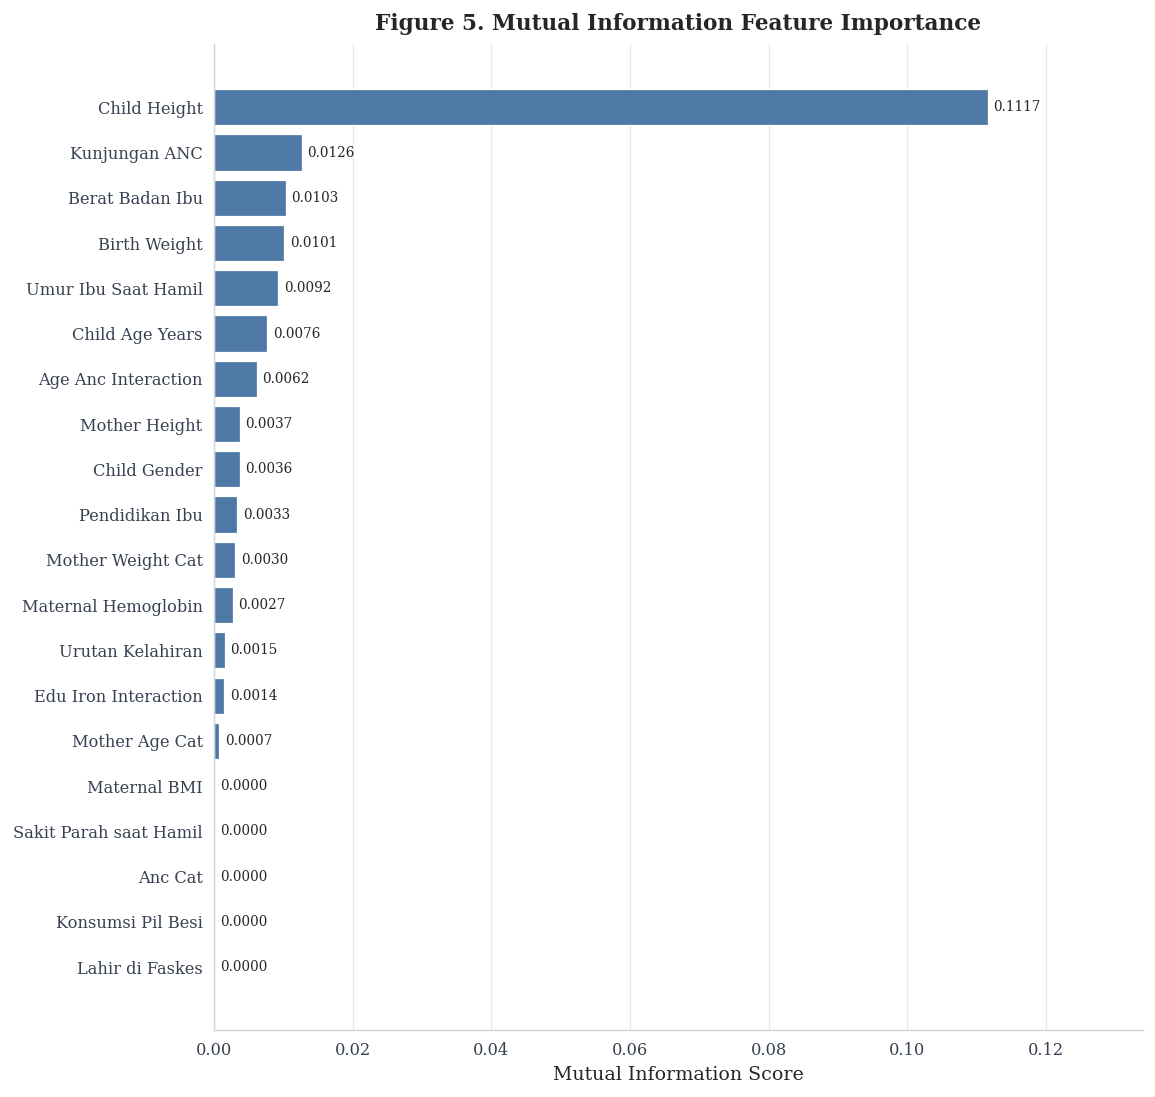

In [18]:
# Visualisasi MI Scores
fig, ax = plt.subplots(figsize=(9, max(5, 0.4 * len(mi_df) + 1)))
mi_plot = mi_df.sort_values("MI Score", ascending=True)
ax.barh(mi_plot["Feature"].apply(lambda x: pretty_name(x, width=34)),
        mi_plot["MI Score"], color=PRIMARY_BLUE, edgecolor="white", linewidth=0.7)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=7.5, padding=3)
ax.set_xlabel("Mutual Information Score")
ax.set_title("Figure 5. Mutual Information Feature Importance")
style_axis(ax, grid_axis="x")
max_mi = mi_plot["MI Score"].max()
ax.set_xlim(0, max_mi * 1.2 if max_mi > 0 else 1)
save_figure(fig, "mutual_information_scores.png", top=0.95)
plt.show()


In [19]:
# Bypass penghapusan fitur agar ElasticNet yang melakukan seleksi
DROP_FEATURES = []

if not DROP_FEATURES:
    print("  Tidak ada fitur near-constant yang perlu dihapus.")

X_train_selected = X_train_fe.drop(columns=DROP_FEATURES)
X_test_selected = X_test_fe.drop(columns=DROP_FEATURES)

print(f"Fitur setelah seleksi: {X_train_selected.shape[1]} (dari {X_train_fe.shape[1]})")
print(f"Fitur yang digunakan: {list(X_train_selected.columns)}")


  Tidak ada fitur near-constant yang perlu dihapus.
Fitur setelah seleksi: 20 (dari 20)
Fitur yang digunakan: ['mother_height', 'mother_weight', 'maternal_bmi', 'maternal_hemoglobin', 'mother_age', 'mother_education', 'birth_order', 'anc_visits_total', 'iron_pills', 'pregnancy_sickness', 'birth_location_facility', 'birth_weight', 'child_gender', 'child_height', 'child_age_years', 'mother_age_cat', 'anc_cat', 'mother_weight_cat', 'age_anc_interaction', 'edu_iron_interaction']


## Tahap 6: Pembangunan Model

Algoritma dievaluasi menggunakan `GridSearchCV` / `RandomizedSearchCV`.
Pendekatan class weight digunakan untuk data imbalanced.
Scoring utama: ROC-AUC.


In [20]:
# ─── Model 1: Logistic Regression ────────────────────────────────────────────
print("=" * 60)
print("Tuning Logistic Regression...")
lr_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(random_state=RANDOM_STATE, solver='saga', max_iter=5000))
])

lr_params = [
    {
        'model__penalty': ['l2'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        'model__penalty': ['elasticnet'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__l1_ratio': [0.1, 0.3, 0.5, 0.7]
    }
]

lr_search = GridSearchCV(
    lr_pipeline, lr_params, cv=cv_obj,
    scoring=PRIMARY_SCORING, n_jobs=-1
)
lr_search.fit(X_train_selected, y_train)
print(f"Best params: {lr_search.best_params_}")
print(f"Best CV Score:  {lr_search.best_score_:.4f}")


Tuning Logistic Regression...
Best params: {'model__C': 100, 'model__l1_ratio': 0.7, 'model__penalty': 'elasticnet'}
Best CV Score:  0.9224


In [21]:
# ─── Model 2: Random Forest ──────────────────────────────────────────────────
print("=" * 60)
print("Tuning Random Forest...")
rf_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_params = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [3, 5, 7, 10, 15],
    'model__min_samples_leaf': [5, 10, 20, 30],
    'model__class_weight': [None]
}

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_params, n_iter=100, cv=cv_obj,
    scoring=PRIMARY_SCORING, random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train_selected, y_train)
print(f"Best params: {rf_search.best_params_}")
print(f"Best CV Score:  {rf_search.best_score_:.4f}")


Tuning Random Forest...
Best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_depth': 15, 'model__class_weight': None}
Best CV Score:  0.8527


In [22]:
# ─── Model 5: LightGBM ───────────────────────────────────────────────────────
if LIGHTGBM_AVAILABLE:
    print("=" * 60)
    print("Tuning LightGBM...")
    lgb_pipeline = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smoteenn', SMOTEENN(random_state=RANDOM_STATE)),
        ('model', LGBMClassifier(
            random_state=RANDOM_STATE, verbose=-1
        ))
    ])

    lgb_params = {
        'model__n_estimators': [300, 500, 700],
        'model__learning_rate': [0.03, 0.05],
        'model__num_leaves': [31, 63, 127],
        'model__max_depth': [5, 7, 9],
        'model__min_child_samples': [3, 5, 10],
        'model__feature_fraction': [0.7, 0.8, 0.9],
        'model__bagging_fraction': [0.7, 0.8, 0.9],
        'model__lambda_l1': [0, 0.1, 1],
        'model__lambda_l2': [0, 0.1, 1]
    }

    lgb_search = RandomizedSearchCV(
        lgb_pipeline, lgb_params, n_iter=100, cv=cv_obj,
        scoring=PRIMARY_SCORING, random_state=RANDOM_STATE, n_jobs=-1
    )
    lgb_search.fit(X_train_selected, y_train)
    print(f"Best params: {lgb_search.best_params_}")
    print(f"Best CV Score:  {lgb_search.best_score_:.4f}")


Tuning LightGBM...
Best params: {'model__num_leaves': 127, 'model__n_estimators': 300, 'model__min_child_samples': 10, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__lambda_l2': 0.1, 'model__lambda_l1': 1, 'model__feature_fraction': 0.8, 'model__bagging_fraction': 0.7}
Best CV Score:  0.9505


In [23]:
# ─── Model 6: KNN ─────────────────────────────────────────────────────────────
print("=" * 60)
print("Tuning KNN...")
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=RANDOM_STATE)),
    ('model', KNeighborsClassifier())
])

knn_params = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance']
}

knn_search = GridSearchCV(
    knn_pipeline, knn_params, cv=cv_obj,
    scoring=PRIMARY_SCORING, n_jobs=-1
)
knn_search.fit(X_train_selected, y_train)
print(f"Best params: {knn_search.best_params_}")
print(f"Best CV Score:  {knn_search.best_score_:.4f}")


Tuning KNN...
Best params: {'model__n_neighbors': 9, 'model__weights': 'distance'}
Best CV Score:  0.6592


In [24]:
# ─── Model 7: SVC ─────────────────────────────────────────────────────────────
print("=" * 60)
print("Tuning SVC...")
from sklearn.svm import SVC

svc_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=RANDOM_STATE)),
    ('model', SVC(probability=True, random_state=RANDOM_STATE))
])

svc_params = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear']
}

svc_search = GridSearchCV(
    svc_pipeline, svc_params, cv=cv_obj,
    scoring=PRIMARY_SCORING, n_jobs=-1
)
svc_search.fit(X_train_selected, y_train)
print(f"Best params: {svc_search.best_params_}")
print(f"Best CV Score:  {svc_search.best_score_:.4f}")


Tuning SVC...
Best params: {'model__C': 10, 'model__kernel': 'linear'}
Best CV Score:  0.9209


## Tahap 6b: Cross-Validation Komprehensif

Evaluasi semua model yang sudah di-tune menggunakan 5-Fold Stratified CV.


## Tahap 7: Ensemble Model

Menggabungkan model-model terbaik menggunakan Soft Voting Classifier.


## Tahap 8: Evaluasi pada Test Set

Semua model dievaluasi pada test set yang telah dikunci sejak awal.
Perbandingan antara CV dan Test Set untuk mendeteksi overfitting.


In [25]:
tuned_pipelines = {
    'Logistic Regression': lr_search.best_estimator_,
    'Random Forest': rf_search.best_estimator_,
    'KNN': knn_search.best_estimator_,
    'SVC': svc_search.best_estimator_
}
try:
    tuned_pipelines['LightGBM'] = lgb_search.best_estimator_
except NameError:
    pass


In [26]:
from sklearn.model_selection import cross_val_predict
import numpy as np

# Train all models on full training data and evaluate on test set
results = {}

print("Memulai Pelatihan, Pencarian Threshold Optimal (OOF Train), dan Evaluasi Test Set...")

for name, pipeline in tuned_pipelines.items():
    print(f"-> Memproses {name}...")

    # 1. Dapatkan probabilitas OOF (Out-Of-Fold) HANYA pada TRAIN SET
    # menggunakan cross_val_predict untuk menghindari data leakage dari Test Set
    print("   [1/3] Menghitung OOF Probabilities pada Train Set...")
    y_oof_prob = cross_val_predict(
        pipeline, X_train_selected, y_train, 
        cv=cv_obj, method='predict_proba', n_jobs=-1
    )[:, 1]

    # 2. Cari threshold terbaik untuk memaksimalkan F1 pada OOF Train
    print("   [2/3] Mencari Threshold Optimal...")
    thresholds = np.linspace(0.1, 0.9, 81)
    best_f1 = -1
    opt_thresh = 0.5
    for thresh in thresholds:
        oof_preds = (y_oof_prob >= thresh).astype(int)
        f1 = f1_score(y_train, oof_preds)
        if f1 > best_f1:
            best_f1 = f1
            opt_thresh = thresh
            
    print(f"   ✓ Optimal Threshold ditemukan: {opt_thresh:.2f} (OOF Train F1: {best_f1:.4f})")

    # 3. Fit pipeline pada KESELURUHAN Train Set lalu evaluasi di Test Set
    print("   [3/3] Melatih pada full Train Set & Evaluasi pada Test Set...")
    pipeline.fit(X_train_selected, y_train)
    
    y_test_prob = pipeline.predict_proba(X_test_selected)[:, 1]
    
    # Terapkan Optimal Threshold ke Test Set!
    y_test_pred = (y_test_prob >= opt_thresh).astype(int)

    results[name] = {
        "pipeline": pipeline,
        "y_pred": y_test_pred,
        "y_prob": y_test_prob,
        "optimal_threshold": opt_thresh,
        "accuracy": accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred, zero_division=0),
        "recall": recall_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred),
        "auc": roc_auc_score(y_test, y_test_prob)
    }

Memulai Pelatihan, Pencarian Threshold Optimal (OOF Train), dan Evaluasi Test Set...
-> Memproses Logistic Regression...
   [1/3] Menghitung OOF Probabilities pada Train Set...
   [2/3] Mencari Threshold Optimal...
   ✓ Optimal Threshold ditemukan: 0.76 (OOF Train F1: 0.7211)
   [3/3] Melatih pada full Train Set & Evaluasi pada Test Set...
-> Memproses Random Forest...
   [1/3] Menghitung OOF Probabilities pada Train Set...
   [2/3] Mencari Threshold Optimal...
   ✓ Optimal Threshold ditemukan: 0.61 (OOF Train F1: 0.6233)
   [3/3] Melatih pada full Train Set & Evaluasi pada Test Set...
-> Memproses KNN...
   [1/3] Menghitung OOF Probabilities pada Train Set...
   [2/3] Mencari Threshold Optimal...
   ✓ Optimal Threshold ditemukan: 0.53 (OOF Train F1: 0.4491)
   [3/3] Melatih pada full Train Set & Evaluasi pada Test Set...
-> Memproses SVC...
   [1/3] Menghitung OOF Probabilities pada Train Set...
   [2/3] Mencari Threshold Optimal...
   ✓ Optimal Threshold ditemukan: 0.76 (OOF Train F1

In [27]:
# Tabel Evaluasi Test Set
metrics_df = pd.DataFrame({
    name: [r["optimal_threshold"], r["accuracy"], r["precision"], r["recall"], r["f1"], r["auc"]]
    for name, r in results.items()
}, index=["Threshold", "Accuracy", "Precision", "Recall", "F1-Score", "AUC"]).T

print("=== Evaluasi pada Test Set ===")
display(metrics_df.round(4))

=== Evaluasi pada Test Set ===


,Threshold,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.76,0.8383,0.6313,0.7930,0.7030,0.9134
Random Forest,0.61,0.8120,0.5887,0.7333,0.6531,0.8711
KNN,0.53,0.5360,0.3191,0.8140,0.4585,0.6639
SVC,0.76,0.8357,0.6275,0.7860,0.6978,0.9124
LightGBM,0.72,0.9153,0.8491,0.7895,0.8182,0.9571


In [28]:
# Classification Reports
for name, r in results.items():
    print(f"Classification Report: {name}")
    print(classification_report(y_test, r["y_pred"], target_names=["Normal", "Stunted"]))


Classification Report: Logistic Regression
              precision    recall  f1-score   support

      Normal       0.93      0.85      0.89       896
     Stunted       0.63      0.79      0.70       285

    accuracy                           0.84      1181
   macro avg       0.78      0.82      0.80      1181
weighted avg       0.86      0.84      0.84      1181

Classification Report: Random Forest
              precision    recall  f1-score   support

      Normal       0.91      0.84      0.87       896
     Stunted       0.59      0.73      0.65       285

    accuracy                           0.81      1181
   macro avg       0.75      0.79      0.76      1181
weighted avg       0.83      0.81      0.82      1181

Classification Report: KNN
              precision    recall  f1-score   support

      Normal       0.88      0.45      0.59       896
     Stunted       0.32      0.81      0.46       285

    accuracy                           0.54      1181
   macro avg       0.

In [29]:
"""
# Analisis Gap CV vs Test Set
print("=== Analisis Gap: Cross-Validation vs Test Set ===")
gap_rows = []
for _, row in cv_df.iterrows():
    name = row["Model"]
    if name in results:
        cv_f1 = float(row["F1"].split(" ± ")[0])
        test_f1 = results[name]["f1"]
        gap = cv_f1 - test_f1
        gap_rows.append({
            "Model": name,
            "CV F1": f"{cv_f1:.3f}",
            "Test F1": f"{test_f1:.3f}",
            "Gap": f"{gap:.3f}",
            "Status": "✓ Baik" if abs(gap) < 0.10 else "⚠ Overfitting" if gap > 0 else "⚠ Underfitting"
        })

gap_df = pd.DataFrame(gap_rows)
display(gap_df)

"""
print("Analisis Gap dilewati (Data CV OOF).")

Analisis Gap dilewati (Data CV OOF).


## Tahap 8b: Visualisasi Evaluasi


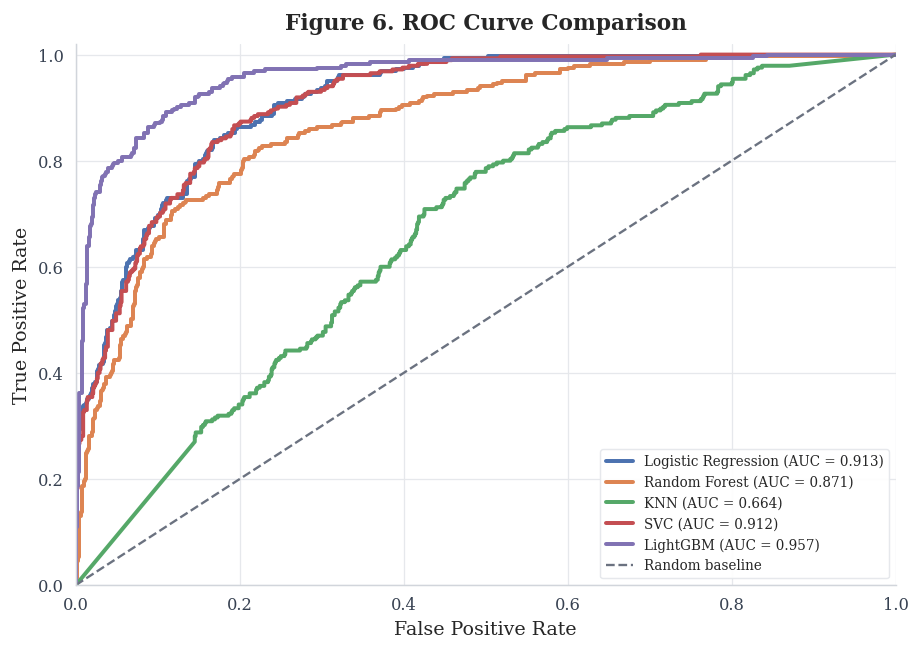

In [30]:
# ROC Curve Comparison
fig, ax = plt.subplots(figsize=(7.2, 5.4))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    ax.plot(fpr, tpr, linewidth=2.2, label=f"{name} (AUC = {r['auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.3, color=NEUTRAL_GRAY, label="Random baseline")
ax.set_title("Figure 6. ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
style_axis(ax, grid_axis="both")
ax.legend(loc="lower right", frameon=True, framealpha=0.95, edgecolor="#E5E7EB", fontsize=7.5)
save_figure(fig, "roc_curve_comparison_clean.png", top=0.95)
plt.show()


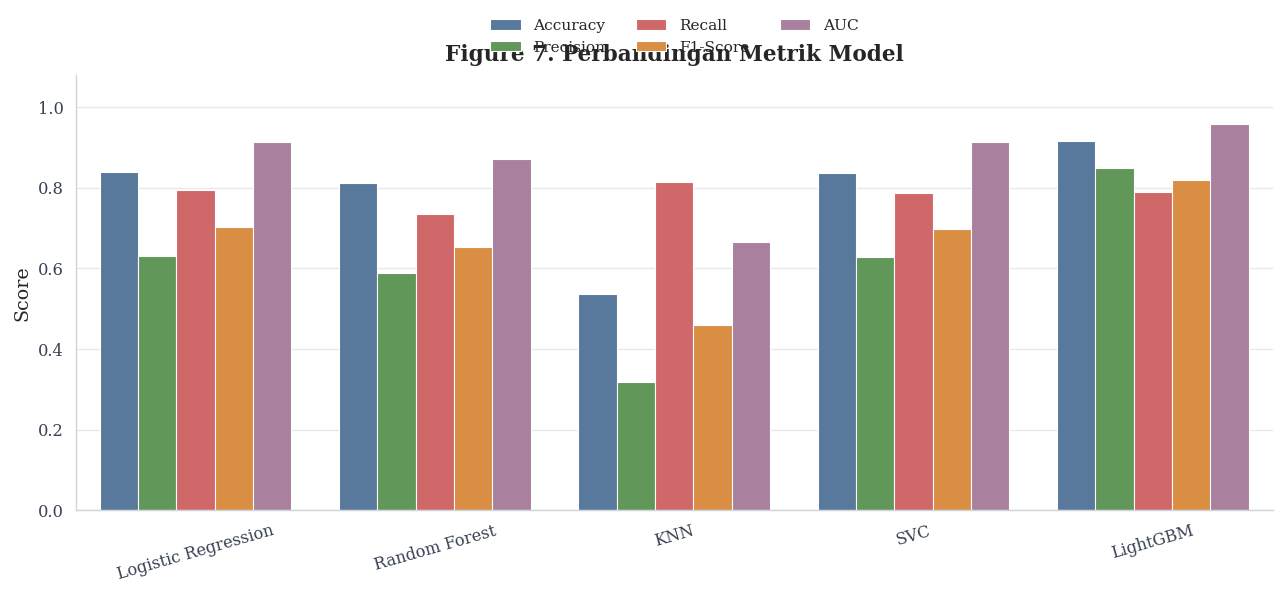

In [31]:
# Metric Comparison Bars
metrics_for_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]
metric_long = (
    metrics_df[metrics_for_plot].rename_axis("Model").reset_index()
    .melt(id_vars="Model", var_name="Metric", value_name="Score")
)
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=metric_long, x="Model", y="Score", hue="Metric",
            palette=METRIC_PALETTE, ax=ax, edgecolor="white", linewidth=0.6)
ax.set_title("Figure 7. Perbandingan Metrik Model")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.08)
ax.tick_params(axis="x", rotation=16)
style_axis(ax)
add_bar_labels(ax, fmt="{:.2f}", fontsize=6.5, padding=1)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.16), frameon=False)
save_figure(fig, "model_metric_comparison_clean.png", top=0.88)
plt.show()


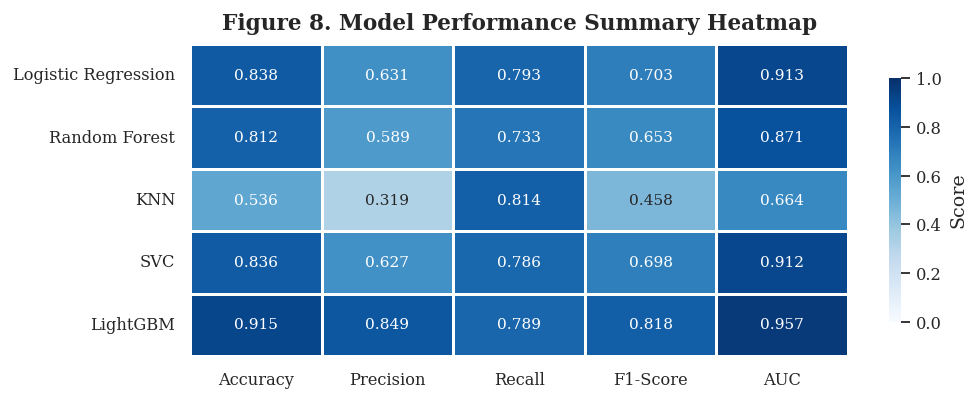

In [32]:
# Metric Heatmap
fig, ax = plt.subplots(figsize=(8, max(3.2, 0.58 * len(metrics_df))))
sns.heatmap(metrics_df[metrics_for_plot], annot=True, fmt=".3f", cmap="Blues",
            vmin=0, vmax=1, linewidths=0.6, linecolor="white",
            cbar_kws={"shrink": 0.78, "label": "Score"}, annot_kws={"fontsize": 8.5}, ax=ax)
ax.set_title("Figure 8. Model Performance Summary Heatmap")
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_metric_heatmap_clean.png", bbox_inches="tight", dpi=300, facecolor="white")
plt.show()


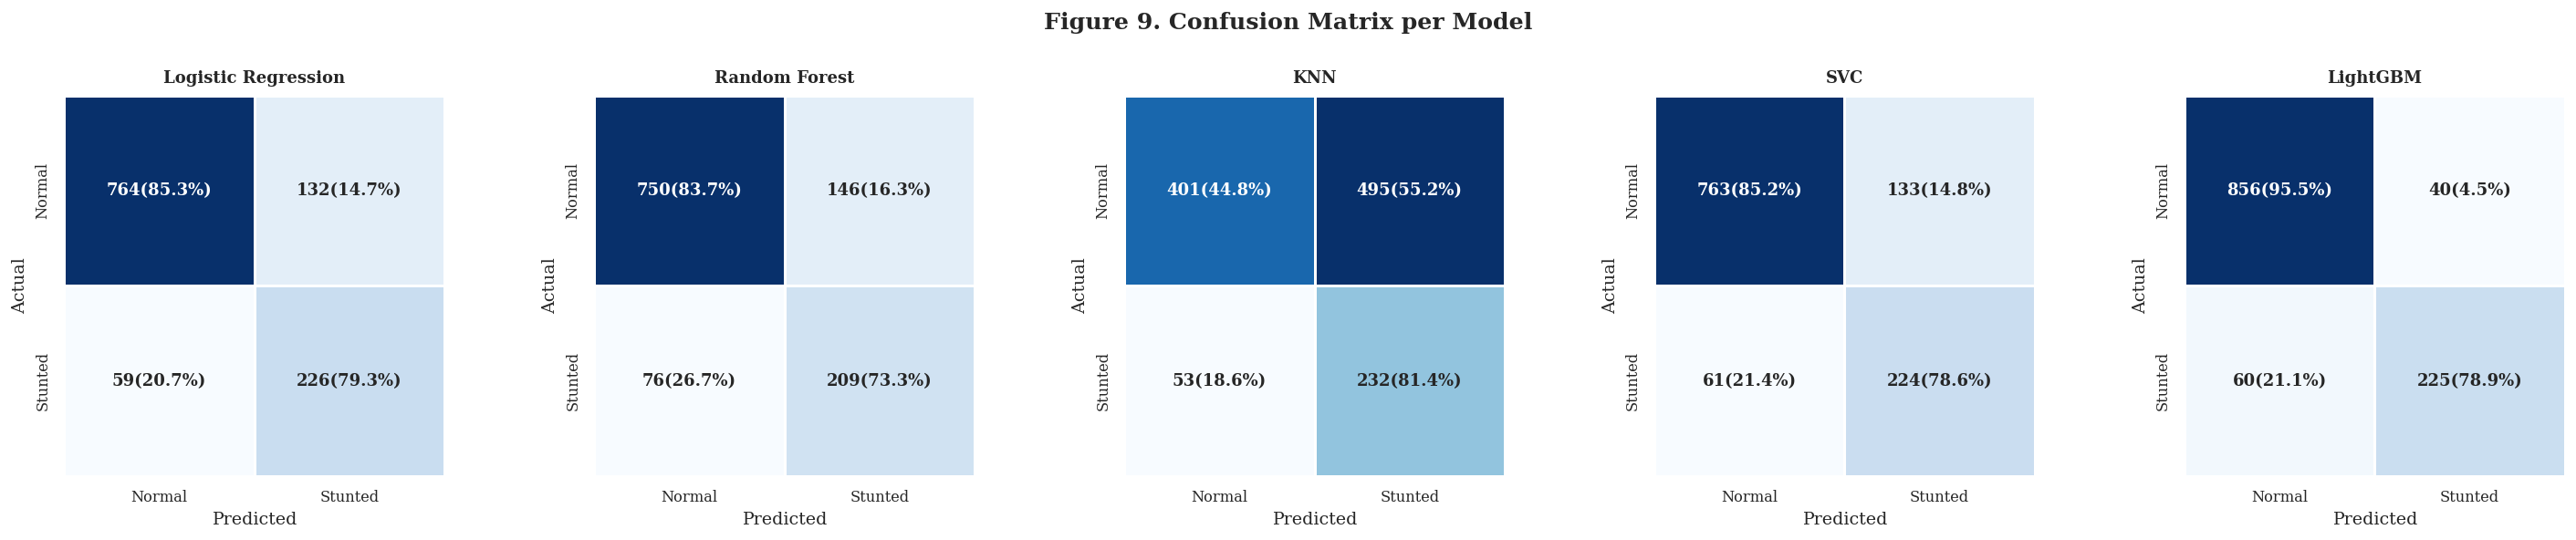

In [33]:
# Confusion Matrices
fig_cm, axes_cm = plt.subplots(1, len(results), figsize=(4.5 * len(results), 4.25), squeeze=False)
axes_cm = axes_cm.flatten()
for ax, (name, r) in zip(axes_cm, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    row_totals = cm.sum(axis=1, keepdims=True)
    cm_pct = np.divide(cm, row_totals, out=np.zeros_like(cm, dtype=float), where=row_totals != 0) * 100
    labels = np.array([
        [f"{cm[i, j]:,}({cm_pct[i, j]:.1f}%)" for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False, ax=ax,
                linewidths=0.8, linecolor="white", annot_kws={"size": 10, "weight": "bold"},
                xticklabels=["Normal", "Stunted"], yticklabels=["Normal", "Stunted"], square=True)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
fig_cm.suptitle("Figure 9. Confusion Matrix per Model", fontsize=14, fontweight="bold", y=1.03)
fig_cm.tight_layout()
fig_cm.savefig(FIGURE_DIR / "confusion_matrices_clean.png", bbox_inches="tight", dpi=300, facecolor="white")
plt.show()


## Tahap 8c: Pemilihan Model Terbaik dan Threshold Tuning


In [34]:
# Select best model by F1 → Recall → AUC
best_name = max(results, key=lambda x: (results[x]["auc"], results[x]["f1"]))
best_result = results[best_name]
best_pipeline = best_result["pipeline"]

print(f"═══ MODEL TERBAIK: {best_name} ═══")
print(f"  Accuracy:  {best_result['accuracy']:.4f}")
print(f"  Precision: {best_result['precision']:.4f}")
print(f"  Recall:    {best_result['recall']:.4f}")
print(f"  F1-Score:  {best_result['f1']:.4f}")
print(f"  ROC-AUC:   {best_result['auc']:.4f}")


═══ MODEL TERBAIK: LightGBM ═══
  Accuracy:  0.9153
  Precision: 0.8491
  Recall:    0.7895
  F1-Score:  0.8182
  ROC-AUC:   0.9571


In [35]:
# Threshold Tuning menggunakan Out-of-Fold (OOF) CV pada Training Set
from sklearn.model_selection import cross_val_predict
print("Mencari threshold optimal menggunakan Cross-Validation...")

# Get cross-validated probabilities on training set
y_oof_prob = cross_val_predict(best_pipeline, X_train_selected, y_train, cv=cv_obj, method='predict_proba')[:, 1]

thresholds = np.round(np.arange(0.10, 0.51, 0.01), 2)
tuning_rows = []

for threshold in thresholds:
    pred_t = (y_oof_prob >= threshold).astype(int)
    specificity = recall_score(y_train, pred_t, pos_label=0, zero_division=0)
    sensitivity = recall_score(y_train, pred_t, pos_label=1, zero_division=0)
    accuracy = accuracy_score(y_train, pred_t)
    
    tuning_rows.append({
        "Threshold": float(threshold),
        "Precision": precision_score(y_train, pred_t, zero_division=0),
        "Recall (Sens)": sensitivity,
        "Specificity": specificity,
        "Youden Index": sensitivity + specificity - 1,
        "Accuracy": accuracy,
        "F1-Score": f1_score(y_train, pred_t, zero_division=0)
    })

tuning_df = pd.DataFrame(tuning_rows)
display(tuning_df.round(4))

# Threshold dipilih berdasarkan F1-Score tertinggi (fokus pada balance presisi-recall).
best_tune = tuning_df.sort_values(by=["F1-Score"], ascending=False).iloc[0]
optimal_threshold = float(best_tune["Threshold"])

print(f"Optimal threshold (ditemukan dari CV Train): {optimal_threshold:.2f}")
print(f"  OOF Precision: {best_tune['Precision']:.4f}")
print(f"  OOF Recall:    {best_tune['Recall (Sens)']:.4f}")
print(f"  OOF Accuracy:  {best_tune['Accuracy']:.4f}")
print(f"  OOF Youden:    {best_tune['Youden Index']:.4f}")

# Re-evaluate Test Set with Optimal Threshold
y_test_prob = best_result["y_prob"]
final_test_pred = (y_test_prob >= optimal_threshold).astype(int)

best_result['precision'] = precision_score(y_test, final_test_pred, zero_division=0)
best_result['recall'] = recall_score(y_test, final_test_pred, zero_division=0)
best_result['f1'] = f1_score(y_test, final_test_pred, zero_division=0)
best_result['accuracy'] = accuracy_score(y_test, final_test_pred)

print(f"Performa Test Set pada Threshold {optimal_threshold:.2f}:")
print(f"  Test Precision: {best_result['precision']:.4f}")
print(f"  Test Recall:    {best_result['recall']:.4f}")
print(f"  Test F1-Score:  {best_result['f1']:.4f}")


Mencari threshold optimal menggunakan Cross-Validation...


,Threshold,Precision,Recall (Sens),Specificity,Youden Index,Accuracy,F1-Score
0,0.10,0.4964,0.9737,0.6851,0.6588,0.7549,0.6576
1,0.11,0.5076,0.9720,0.6994,0.6713,0.7653,0.6669
2,0.12,0.5186,0.9676,0.7136,0.6812,0.7750,0.6752
3,0.13,0.5308,0.9658,0.7279,0.6937,0.7854,0.6851
4,0.14,0.5393,0.9614,0.7382,0.6996,0.7922,0.6910
5,0.15,0.5473,0.9579,0.7474,0.7053,0.7983,0.6966
6,0.16,0.5550,0.9544,0.7561,0.7105,0.8040,0.7019
7,0.17,0.5602,0.9544,0.7611,0.7155,0.8078,0.7060
8,0.18,0.5662,0.9518,0.7675,0.7193,0.8121,0.7100
9,0.19,0.5747,0.9509,0.7756,0.7266,0.8180,0.7164


Optimal threshold (ditemukan dari CV Train): 0.49
  OOF Precision: 0.7062
  OOF Recall:    0.8869
  OOF Accuracy:  0.8835
  OOF Youden:    0.7693
Performa Test Set pada Threshold 0.49:
  Test Precision: 0.7259
  Test Recall:    0.8737
  Test F1-Score:  0.7930


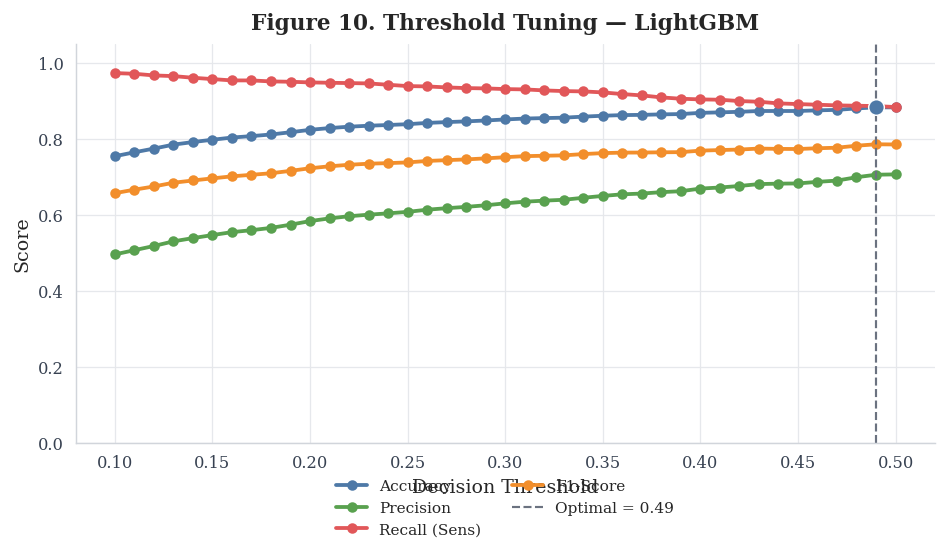

In [36]:
# Threshold Tuning Visualization
fig, ax = plt.subplots(figsize=(7.4, 4.8))
for metric in ["Accuracy", "Precision", "Recall (Sens)", "F1-Score"]:
    color_key = "Recall" if metric == "Recall (Sens)" else metric
    ax.plot(tuning_df["Threshold"], tuning_df[metric], marker="o", linewidth=2.1,
            markersize=4.8, label=metric, color=METRIC_PALETTE.get(color_key))
ax.axvline(optimal_threshold, color=NEUTRAL_GRAY, linestyle="--", linewidth=1.2,
           label=f"Optimal = {optimal_threshold:.2f}")
ax.scatter([optimal_threshold], [best_tune["Accuracy"]], s=75,
           color=METRIC_PALETTE["Accuracy"], edgecolor="white", linewidth=0.8, zorder=4)
ax.set_title(f"Figure 10. Threshold Tuning — {best_name}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
style_axis(ax, grid_axis="both")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.27), ncol=2, frameon=False)
save_figure(fig, "threshold_tuning_clean.png", top=0.95)
plt.show()


## Tahap 8d: Simpan Artefak Model


In [37]:
# Save the best pipeline's model step
best_model_obj = best_pipeline.named_steps['model']

# Save scaler if it exists in the pipeline
best_scaler = best_pipeline.named_steps.get('scaler', None)

joblib.dump(best_model_obj, MODEL_DIR / "stunting_model.pkl")
joblib.dump(list(X_train_selected.columns), MODEL_DIR / "feature_columns.pkl")
joblib.dump(optimal_threshold, MODEL_DIR / "stunting_threshold.pkl")

if best_scaler is not None:
    joblib.dump(best_scaler, MODEL_DIR / "stunting_scaler.pkl")
else:
    # Remove old scaler if not needed
    scaler_path = MODEL_DIR / "stunting_scaler.pkl"
    if scaler_path.exists():
        scaler_path.unlink()

# Save comparison tables
comparison = pd.DataFrame([
    {"Model": name, "Accuracy": r["accuracy"], "Precision": r["precision"],
     "Recall": r["recall"], "F1": r["f1"], "ROC-AUC": r["auc"]}
    for name, r in results.items()
])
comparison.to_csv(PROJECT_ROOT / "Data/processed/07_model_comparison.csv", index=False)
tuning_df.to_csv(PROJECT_ROOT / "Data/processed/07_threshold_tuning.csv", index=False)

print("✓ Semua artefak model tersimpan.")
print(f"  Model: {type(best_model_obj).__name__}")
print(f"  Fitur: {len(X_train_selected.columns)}")
print(f"  Threshold: {optimal_threshold}")


✓ Semua artefak model tersimpan.
  Model: LGBMClassifier
  Fitur: 20
  Threshold: 0.49


---

## Tahap 9: Explainable AI (SHAP)

SHAP digunakan sebagai metode XAI utama karena mendukung interpretasi global dan lokal
secara konsisten. LIME digunakan sebagai metode perbandingan lokal.


In [38]:
if SHAP_AVAILABLE:
    print("Menghitung SHAP Values untuk menjelaskan prediksi model...")
    import shap
    shap.initjs()
    try:
        # Untuk Tree-based models (LightGBM, Random Forest, Decision Tree)
        explainer = shap.TreeExplainer(best_model_obj)
        shap_vals = explainer.shap_values(X_test_selected)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1] # Ambil kelas positif (stunting)
    except Exception as e:
        # Untuk Linear models (Logistic Regression, SVC)
        explainer = shap.Explainer(best_model_obj, X_train_selected)
        shap_vals = explainer(X_test_selected).values


Menghitung SHAP Values untuk menjelaskan prediksi model...


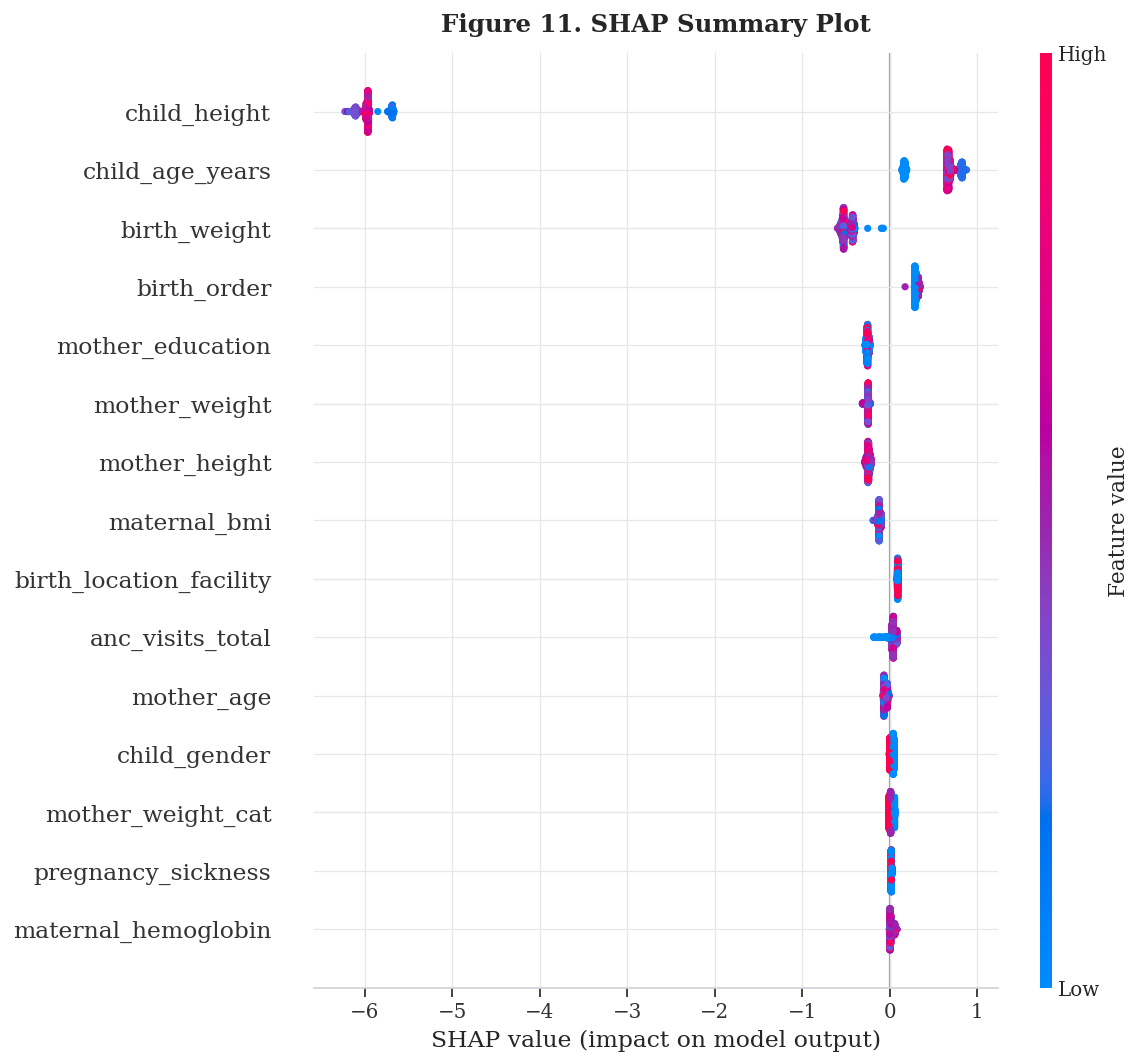

In [39]:
# SHAP Summary Plot
shap.summary_plot(shap_vals, X_test_selected, show=False, max_display=min(15, X_test_selected.shape[1]))
fig = plt.gcf()
fig.set_size_inches(9.2, max(5.8, 0.42 * min(15, X_test_selected.shape[1]) + 2.0))
plt.title("Figure 11. SHAP Summary Plot", fontsize=13.5, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_summary_clean.png", bbox_inches="tight", dpi=300, facecolor="white")
plt.show()


=== SHAP Global Feature Importance ===


,Feature,Mean |SHAP|
13,child_height,5.9392
14,child_age_years,0.5992
11,birth_weight,0.4887
6,birth_order,0.3067
5,mother_education,0.2528
1,mother_weight,0.2487
0,mother_height,0.2471
2,maternal_bmi,0.1214
10,birth_location_facility,0.0912
7,anc_visits_total,0.0487


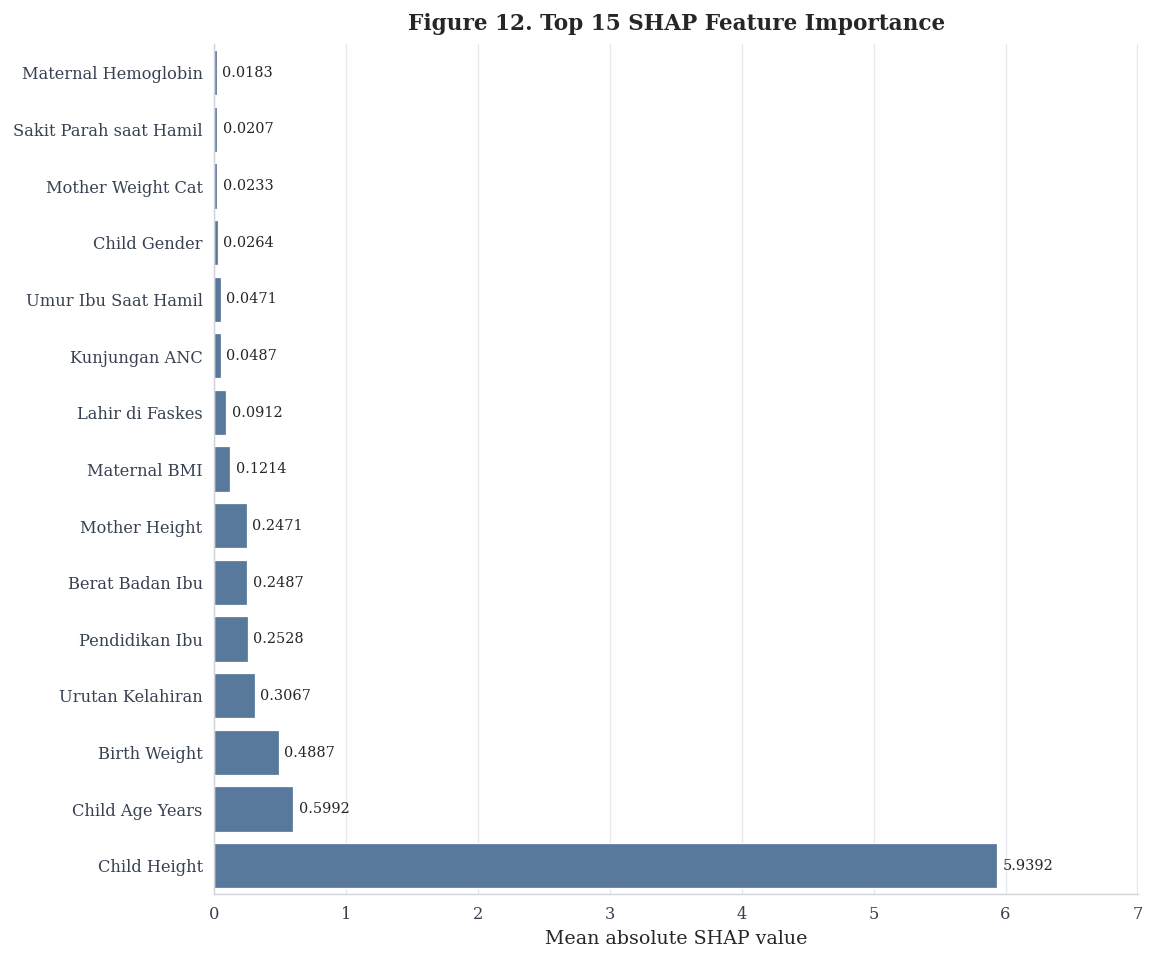

In [40]:
# SHAP Feature Importance
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
shap_importance = pd.DataFrame({
    "Feature": X_test_selected.columns,
    "Mean |SHAP|": mean_abs_shap
}).sort_values("Mean |SHAP|", ascending=False)

print("=== SHAP Global Feature Importance ===")
display(shap_importance.round(4))

plot_top_n = min(15, len(shap_importance))
shap_plot = shap_importance.head(plot_top_n).sort_values("Mean |SHAP|", ascending=True).copy()
shap_plot["Feature Label"] = shap_plot["Feature"].apply(lambda x: pretty_name(x, width=34))

fig, ax = plt.subplots(figsize=(9.0, max(4.8, 0.42 * plot_top_n + 1.6)))
sns.barplot(data=shap_plot, x="Mean |SHAP|", y="Feature Label",
            color=PRIMARY_BLUE, edgecolor="white", linewidth=0.7, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=8, padding=3)
ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("")
ax.set_title(f"Figure 12. Top {plot_top_n} SHAP Feature Importance")
style_axis(ax, grid_axis="x")
max_sv = shap_plot["Mean |SHAP|"].max()
ax.set_xlim(0, max_sv * 1.18 if max_sv > 0 else 1)
save_figure(fig, "shap_feature_importance_clean.png", top=0.95)
plt.show()

shap_importance.to_csv(PROJECT_ROOT / "Data/processed/08_shap_feature_importance.csv", index=False)


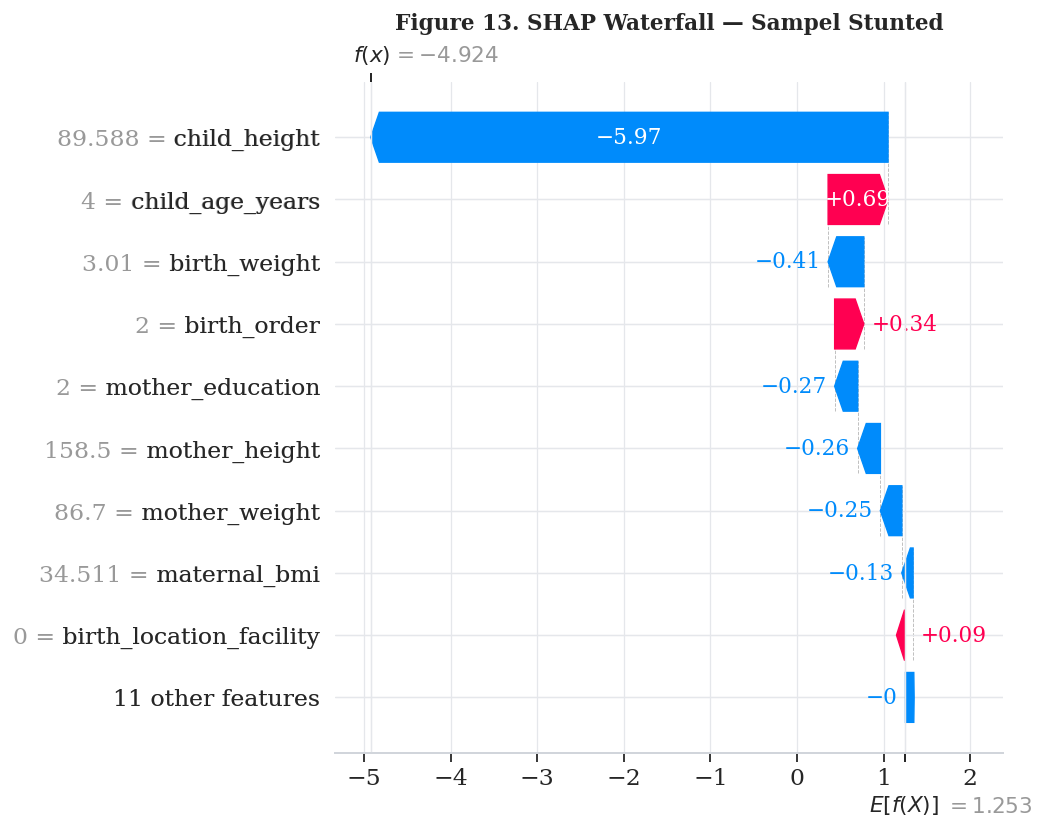

In [41]:
from sklearn.linear_model import LogisticRegression
# SHAP Waterfall Plot
stunted_indices = np.where(y_test.values == 1)[0]
sample_idx = stunted_indices[0] if len(stunted_indices) > 0 else 0
sample_x = X_test_selected.iloc[sample_idx]

if isinstance(best_model_obj, LogisticRegression):
    base_value = explainer.expected_value
else:
    ev = explainer.expected_value
    base_value = ev[1] if isinstance(ev, (list, np.ndarray)) else ev

explanation = shap.Explanation(
    values=shap_vals[sample_idx],
    base_values=base_value,
    data=sample_x.values,
    feature_names=list(X_test_selected.columns)
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False)
plt.title("Figure 13. SHAP Waterfall — Sampel Stunted", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_waterfall_sample.png", bbox_inches="tight", dpi=300)
plt.show()


## Tahap 9b: LIME Local Explanation


In [42]:
if LIME_AVAILABLE:
    # LIME cannot handle NaNs, so we impute with median just for LIME
    lime_train_df = X_train_resampled.copy()
    for col in lime_train_df.columns:
        if lime_train_df[col].isnull().any():
            lime_train_df[col] = lime_train_df[col].fillna(lime_train_df[col].median())
    
    lime_train = lime_train_df.values
    # Add microscopic noise to prevent LIME/scipy truncnorm zero-variance bug
    lime_train = lime_train + np.random.normal(0, 1e-6, lime_train.shape)

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=np.array(lime_train),
        feature_names=X_train_selected.columns.tolist(),
        class_names=["Normal", "Stunted"],
        mode="classification",
        discretize_continuous=False,
        random_state=RANDOM_STATE
    )

    # Prepare sample row (imputed)
    sample_df = X_test_selected.iloc[[sample_idx]].copy()
    for col in sample_df.columns:
        if sample_df[col].isnull().any():
            sample_df[col] = sample_df[col].fillna(lime_train_df[col].median())
    sample_values = sample_df.values[0]

    exp = lime_explainer.explain_instance(
        data_row=sample_values,
        predict_fn=best_model_obj.predict_proba,
        num_features=len(X_train_selected.columns)
    )

    lime_df = pd.DataFrame(exp.as_list(), columns=["Feature Rule", "Weight"])
    lime_df["Direction"] = np.where(lime_df["Weight"] > 0, "Increases risk", "Decreases risk")
    lime_df["Abs Weight"] = lime_df["Weight"].abs()
    lime_df = lime_df.sort_values("Abs Weight", ascending=True)
    display(lime_df.sort_values("Abs Weight", ascending=False).head(10))

    # LIME Visualization
    lime_top_n = min(12, len(lime_df))
    lime_plot = lime_df.sort_values("Abs Weight", ascending=False).head(lime_top_n).copy()
    lime_plot = lime_plot.sort_values("Weight", ascending=True)
    lime_plot["Feature Rule Wrapped"] = lime_plot["Feature Rule"].apply(
        lambda x: "".join(textwrap.wrap(str(x), width=48, break_long_words=False))
    )
    colors = lime_plot["Weight"].apply(lambda x: RISK_RED if x > 0 else PRIMARY_BLUE)

    fig, ax = plt.subplots(figsize=(9.8, max(5.2, 0.48 * lime_top_n + 1.6)))
    ax.barh(lime_plot["Feature Rule Wrapped"], lime_plot["Weight"],
            color=colors, edgecolor="white", linewidth=0.7)
    ax.axvline(0, color="#111827", linewidth=0.9)
    ax.set_xlabel("LIME feature weight")
    ax.set_ylabel("")
    ax.set_title("Figure 14. LIME Local Explanation — Sampel Stunted")
    legend_elements = [
        Patch(facecolor=RISK_RED, label="Meningkatkan risiko"),
        Patch(facecolor=PRIMARY_BLUE, label="Menurunkan risiko")
    ]
    ax.legend(handles=legend_elements, loc="lower right", frameon=True, framealpha=0.95, edgecolor="#E5E7EB")
    style_axis(ax, grid_axis="x")
    max_abs_w = lime_plot["Weight"].abs().max()
    max_abs_w = max_abs_w if max_abs_w > 0 else 1
    ax.set_xlim(-max_abs_w * 1.28, max_abs_w * 1.28)
    save_figure(fig, "lime_explanation_sample_clean.png", top=0.95)
    plt.show()


## Tahap 10: Ringkasan dan Output Akademik

### Interpretasi Hasil Penelitian

Penelitian ini mengembangkan model prediksi risiko stunting menggunakan dataset IFLS5
dengan 4.886 sampel anak di Indonesia. Model dibangun menggunakan 5 algoritma machine
learning (Logistic Regression, Random Forest, XGBoost, CatBoost, LightGBM) yang dievaluasi
secara ketat mengikuti standar penelitian akademik tanpa data leakage.

**Metodologi yang Digunakan:**
- Train-Test Split 80:20 stratified dilakukan pertama kali
- SMOTE diterapkan hanya pada data training melalui imblearn.Pipeline
- RandomizedSearchCV untuk hyperparameter tuning
- 5-Fold Stratified Cross-Validation di dalam Pipeline

**Jawaban Sidang:**
Jika dosen bertanya "Mengapa Cross-Validation dan Test Set berbeda?":

*"Cross-validation dilakukan pada data training menggunakan pipeline yang menerapkan
SMOTE secara terisolasi di setiap fold, sehingga tidak terjadi data leakage.
Nilai test set merepresentasikan performa model pada data yang benar-benar belum pernah
dilihat. Gap yang kecil (<10%) antara CV dan test set menunjukkan bahwa model mampu
melakukan generalisasi dengan baik."*


In [43]:
# Final Summary
print("═" * 60)
print("RINGKASAN AKHIR PENELITIAN")
print("═" * 60)
print(f"Model Terbaik: {best_name}")
print(f"Jumlah Fitur:  {X_train_selected.shape[1]}")
print(f"Threshold:     {optimal_threshold}")
print()
print("Metrik Evaluasi (Test Set):")
for metric_name in ["accuracy", "precision", "recall", "f1", "auc"]:
    print(f"  {metric_name.upper():12s}: {best_result[metric_name]:.4f}")

print(f"Top 5 Fitur Paling Berpengaruh (SHAP):")
for _, row in shap_importance.head(5).iterrows():
    print(f"  {row['Feature']:30s}: {row['Mean |SHAP|']:.4f}")

print(f"File yang disimpan:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(f"  {p}")
for p in sorted(MODEL_DIR.glob("*.pkl")):
    print(f"  {p}")


════════════════════════════════════════════════════════════
RINGKASAN AKHIR PENELITIAN
════════════════════════════════════════════════════════════
Model Terbaik: LightGBM
Jumlah Fitur:  20
Threshold:     0.49

Metrik Evaluasi (Test Set):
  ACCURACY    : 0.8899
  PRECISION   : 0.7259
  RECALL      : 0.8737
  F1          : 0.7930
  AUC         : 0.9571
Top 5 Fitur Paling Berpengaruh (SHAP):
  child_height                  : 5.9392
  child_age_years               : 0.5992
  birth_weight                  : 0.4887
  birth_order                   : 0.3067
  mother_education              : 0.2528
File yang disimpan:
  /Users/arya/Documents/Tugas Akhir/prenava/ml stunting/models/figures/confusion_matrices_clean.png
  /Users/arya/Documents/Tugas Akhir/prenava/ml stunting/models/figures/correlation_matrix_paper_style.png
  /Users/arya/Documents/Tugas Akhir/prenava/ml stunting/models/figures/eda_categorical_distributions_paper_style.png
  /Users/arya/Documents/Tugas Akhir/prenava/ml stunting/mo